In [21]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('/home/Research/Dataset/ETTh1.csv')

<Axes: title={'center': 'OT'}>

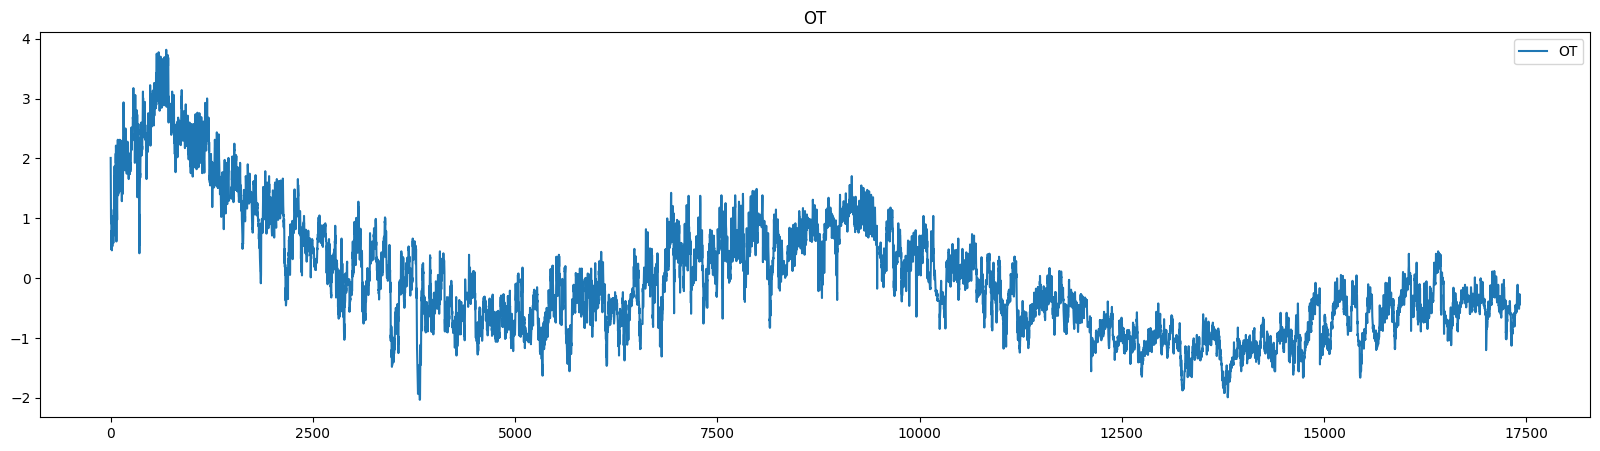

In [22]:
df_scaler = df[['OT']].copy()
df_mean = df_scaler.mean()
df_std = df_scaler.std()
df_scaler['OT'] = (df_scaler['OT'] - df_mean['OT']) / df_std['OT']
df_scaler.plot(figsize=(20, 5), title='OT')

<Axes: title={'center': 'OT'}>

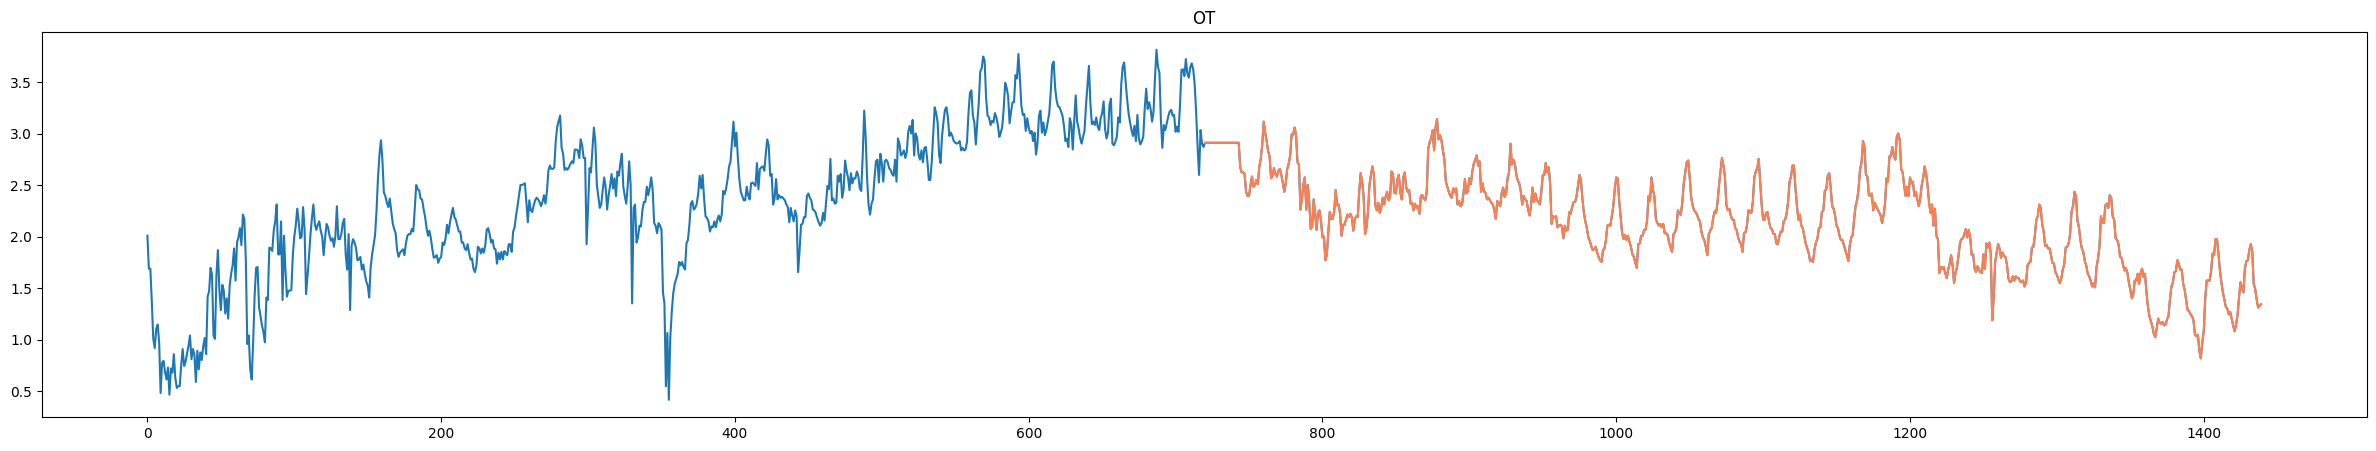

In [23]:
ax = df_scaler['OT'][:1440].plot(figsize=(30, 5), title='OT')
df_scaler['OT'][720:1440].plot(ax=ax, color='coral')

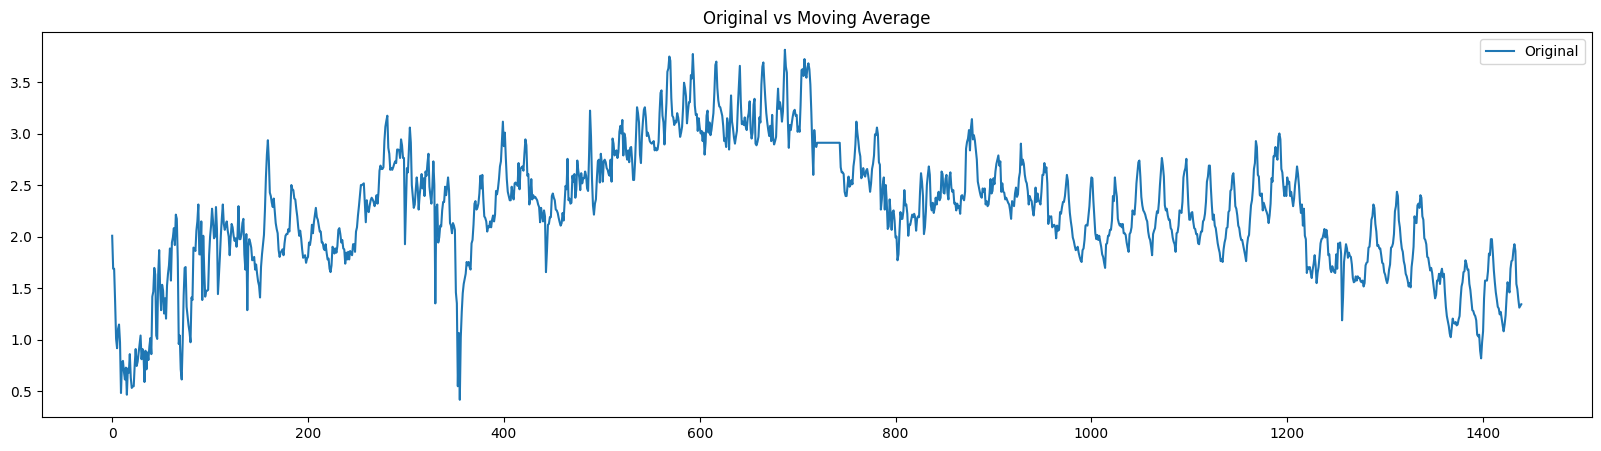

In [ ]:
# 이동평균(Moving Average)으로 시계열 분해
window = 24  # 하루 단위(24시간) 이동평균
seasonal = df_scaler['OT'][:1440].rolling(window=window, center=True).mean()
trend = df_scaler['OT'][:1440] - seasonal

plt.figure(figsize=(20, 5))
plt.plot(df_scaler['OT'][:1440], label='Original')
plt.legend()
plt.title('Original vs Moving Average')
plt.show()

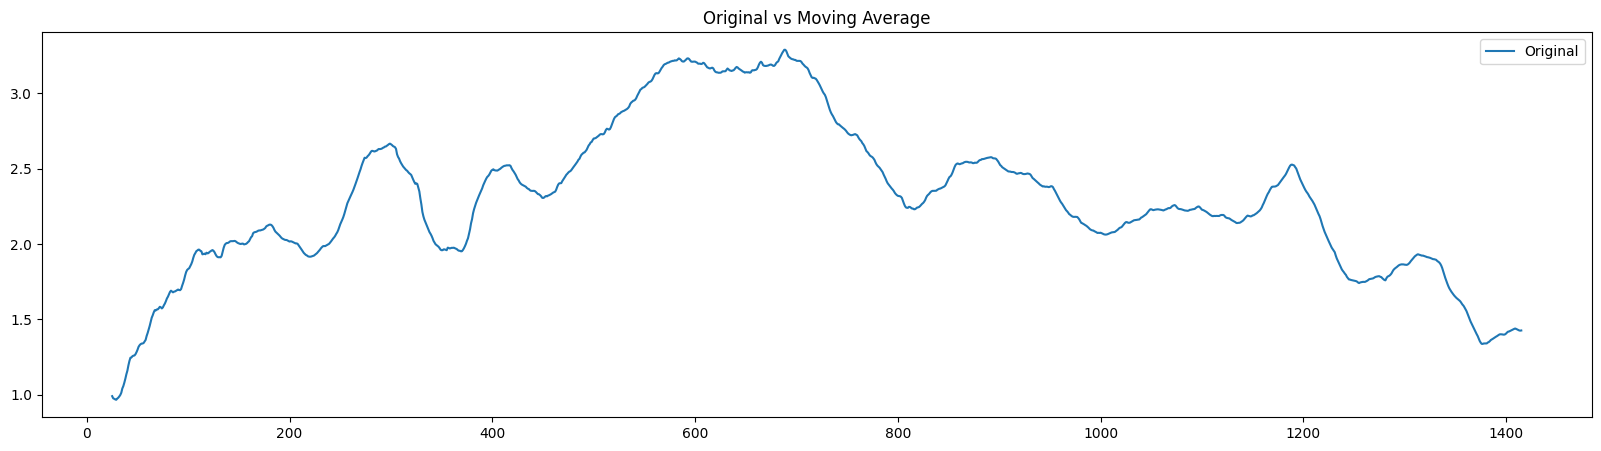

In [37]:
plt.figure(figsize=(20, 5))
plt.plot(seasonal, label='Original')
plt.legend()
plt.title('Original vs Moving Average')
plt.show()

<Axes: title={'center': 'OT'}>

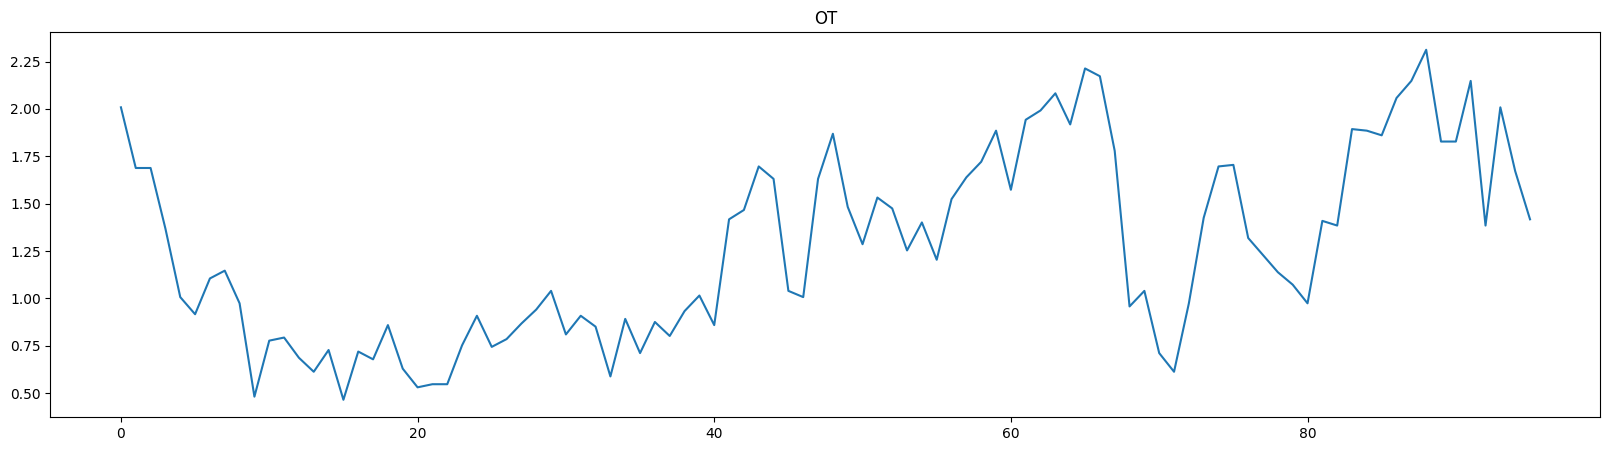

In [24]:
df_scaler['OT'][:96].plot(figsize=(20, 5), title='OT')
# for x in range(24, 97, 24):
#   plt.axvline(x, color='r', linestyle='--', linewidth=1)

/home/anaconda3/envs/research/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


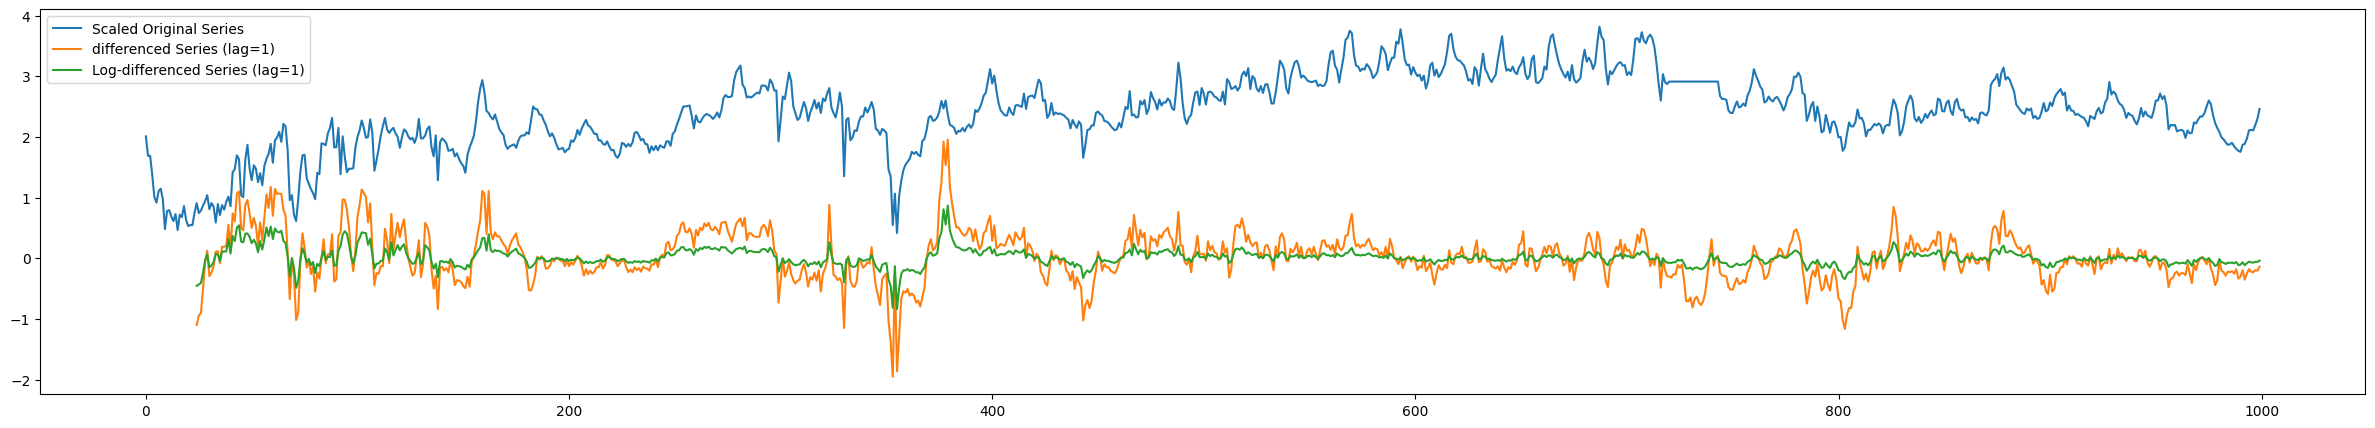

In [25]:
import numpy as np

seasonal_diff_scaler = df_scaler['OT'].diff(periods=24)
log_diff = np.log1p(df_scaler['OT']).diff(periods=24)

plt.figure(figsize=(30, 5))
plt.plot(df_scaler['OT'][:1000], label='Scaled Original Series')
plt.plot(seasonal_diff_scaler[:1000], label='differenced Series (lag=1)')
plt.plot(log_diff[:1000], label='Log-differenced Series (lag=1)')
plt.legend()
plt.show()